# Load data

In [7]:
import scipy.io
import numpy as np
mat = scipy.io.loadmat("Xtrain.mat")
y = mat["Xtrain"].squeeze().astype(np.float32)
print(y)

[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.  48.  23.  19.  27.
  59. 129. 129.  58.  27.  19.  24.  46. 112. 144.  73.  30.  20.  19.
  37.  92. 152.  93.  36.  20.  18.  29.  71. 146. 117.  46.  23.  18.
  22.  52. 128. 142.  62.  26.  17.  19.  37. 100. 158.  86.  32.  17.
  17.  27.  72. 154. 118.  43.  20.  15.  21.  47. 128. 150.  63.  24.
  16.  17.  33.  92. 166.  95.  33.  16.  14.  22.  58. 149. 137.  50.
  20.  15.  16.  35. 106. 169.  82.  28.  15.  14.  23.  65. 160. 133.
  45.  18.  14.  16.  36. 111. 176.  80.  26.  14.  13.  20.  60. 163.
 140.  45.  18.  12.  14.  30.  98. 185.  93.  28.  14.  12.  17.  46.
 145. 167.  58.  19.  11.  12.  21.  68. 183. 132.  38.  15.  11.  13.
  26.  93. 202. 100.  27.  12.  10.  13.  30. 114. 206.  82.  21.  11.
   9.  10.  30. 120. 215.  77.  20.  10.   8.   9.  21.  95. 234.  99.
  22.   9.   8.   7.   9.  35. 176. 215.  46.  11.   7.   5.   4.   3.
   4.  19. 105. 125.  55.  30.  28.  41.  71.  98.  79.  49.  34.  33.
  47. 

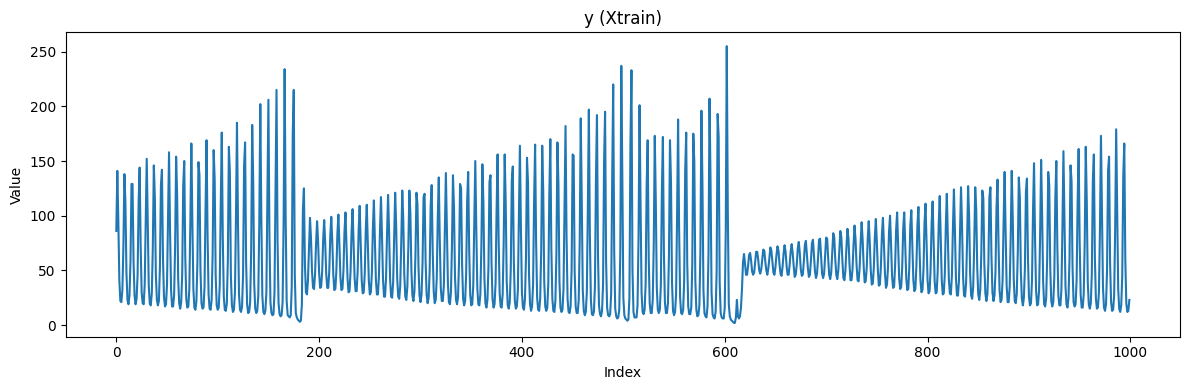

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("y (Xtrain)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# Split train and validation data

In [12]:
N = len(y)

train_end = int(0.8 * N)

y_train = y[:train_end]
y_val = y[train_end:]

In [13]:
mu = y_train.mean()
sigma = y_train.std()

y_train_scaled = (y_train - mu) / sigma
y_val_scaled = (y_val - mu) / sigma

In [14]:
def past_windows_parameter(y_scaled, p):
    X = []
    T = []

    for i in range(len(y_scaled) - p):
        X.append(y_scaled[i:i+p])
        T.append(y_scaled[i+p])

    X = np.array(X, dtype=np.float32)
    T = np.array(T, dtype=np.float32).reshape(-1, 1)

    return X, T

In [15]:
p = 10

X_train, T_train = past_windows_parameter(y_train_scaled, p)
X_val, T_val = past_windows_parameter(y_val_scaled, p)

print("X_train:", X_train.shape)
print("T_train:", T_train.shape)
print("X_val:", X_val.shape)
print("T_val:", T_val.shape)

X_train: (790, 10)
T_train: (790, 1)
X_val: (190, 10)
T_val: (190, 1)


# convert to PyTorch tensors

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
T_val_tensor = torch.tensor(T_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, T_train_tensor)
val_dataset = TensorDataset(X_val_tensor, T_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)